# 12 - OLS y fixed effects temporales (`v2`)

Esta notebook estudia el eje temporal del programa OLS:

> ¿Queda heterogeneidad temporal residual después de controlar por las características observables del modelo core?

La comparación principal usa cuatro especificaciones:

1. `ols_core` — benchmark actual.
2. `ols_core_year_fe` — agrega fixed effects de año.
3. `ols_core_quarter_fe` — agrega fixed effects de trimestre.
4. `ols_core_year_plus_quarter_fe` — agrega fixed effects aditivos de año y trimestre.

Nota metodológica: en esta versión se mantiene `ols_core` como baseline porque los artifacts disponibles fueron generados así. Si después se actualiza el backend para usar `ols_core_no_pyramid`, la estructura de esta notebook sigue siendo la misma: solo cambian los ids de experimento.

La notebook evita gráficos de pocos números. Las métricas agregadas van como tablas. Las figuras se reservan para los fenómenos que sí requieren visualización:

- cómo los FE reducen residuales medios por grupos temporales;
- qué estructura queda en las celdas año×trimestre;
- cómo se separa la media observada del ingreso de la media predicha por el modelo;
- qué expectativas teóricas de los FE se confirman empíricamente.


## 00. Setup y descubrimiento de runs

La notebook consume artifacts ya producidos por el backend. No entrena modelos.

Layout esperado:

```text
reports/runs/<run_id>/
  metrics/model_comparison.csv
  predictions/validation_predictions.parquet
  predictions/test_predictions.parquet
  diagnostics/*fixed_effect*coefficients*.csv
  feature_columns.json
  dataset_card.json
  config_used.yaml
```

También necesita el dataset procesado para recuperar `ANO4` y `TRIMESTRE` a partir de `row_id`.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yaml
except ImportError:
    yaml = None


ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/home/matias/repos/income-modeling-eph"),
]

ROOT = next(
    (p for p in ROOT_CANDIDATES if (p / "reports" / "runs").exists()),
    Path("/home/matias/repos/income-modeling-eph"),
)

RUNS_DIR = ROOT / "reports" / "runs"
DATASET_PATH = ROOT / "data" / "processed" / "modeling_dataset.parquet"

OUTPUT_DIR = ROOT / "reports" / "notebook_outputs" / "ols_temporal_effects_v2"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 140)

print("ROOT:", ROOT)
print("RUNS_DIR:", RUNS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


def read_json_if_exists(path: Path):
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def read_yaml_if_exists(path: Path):
    if not path.exists() or yaml is None:
        return None
    return yaml.safe_load(path.read_text(encoding="utf-8"))


def read_csv_if_exists(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def read_parquet_if_exists(path: Path) -> pd.DataFrame:
    return pd.read_parquet(path) if path.exists() else pd.DataFrame()


ROOT: /home/matias/repos/income-modeling-eph
RUNS_DIR: /home/matias/repos/income-modeling-eph/reports/runs
OUTPUT_DIR: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/ols_temporal_effects_v2


## 01. Especificaciones canónicas

La comparación temporal es acotada: año, trimestre y su suma aditiva. Esto permite usar la notebook como una prueba controlada de fixed effects.

Importante: `year + quarter FE` no es lo mismo que `year × quarter FE`. El primero corrige márgenes; el segundo corregiría celdas calendario específicas.


In [2]:
RUN_PATTERNS = {
    "ols_core": "ols_core_*",
    "ols_core_year_fe": "ols_core_year_fe_*",
    "ols_core_quarter_fe": "ols_core_quarter_fe_*",
    "ols_core_year_plus_quarter_fe": "ols_core_year_plus_quarter_fe_*",
}

ORDER = [
    "ols_core",
    "ols_core_year_fe",
    "ols_core_quarter_fe",
    "ols_core_year_plus_quarter_fe",
]

DISPLAY_LABELS = {
    "ols_core": "Core OLS",
    "ols_core_year_fe": "+ Año FE",
    "ols_core_quarter_fe": "+ Trimestre FE",
    "ols_core_year_plus_quarter_fe": "+ Año + trimestre FE",
}

FE_LABELS = {
    "ols_core": "Sin FE temporales",
    "ols_core_year_fe": "Año",
    "ols_core_quarter_fe": "Trimestre",
    "ols_core_year_plus_quarter_fe": "Año + trimestre",
}

ORDER_INDEX = {exp: i for i, exp in enumerate(ORDER)}

TEMPORAL_SUFFIXES_TO_EXCLUDE_FROM_CORE_FALLBACK = [
    "year_fe", "quarter_fe", "year_plus_quarter_fe", "no_pyramid", "region_fe", "aglo_fe", "geo"
]


def discover_runs() -> dict[str, Path | None]:
    # Se prioriza match exacto por config_used.yaml. El fallback evita confundir ols_core con runs derivados.
    runs = {}
    for experiment, pattern in RUN_PATTERNS.items():
        candidates = sorted(RUNS_DIR.glob(pattern), key=lambda p: p.name)
        if not candidates:
            runs[experiment] = None
            continue

        exact = []
        for candidate in candidates:
            config = read_yaml_if_exists(candidate / "config_used.yaml") or {}
            experiment_id = ((config.get("experiment") or {}).get("id"))
            if experiment_id == experiment:
                exact.append(candidate)

        if exact:
            runs[experiment] = exact[-1]
            continue

        if experiment == "ols_core":
            filtered = [
                p for p in candidates
                if not any(suffix in p.name for suffix in TEMPORAL_SUFFIXES_TO_EXCLUDE_FROM_CORE_FALLBACK)
            ]
            runs[experiment] = filtered[-1] if filtered else candidates[-1]
        else:
            runs[experiment] = candidates[-1]
    return runs


RUNS = discover_runs()

run_table = pd.DataFrame(
    [
        {"experiment": exp, "label": DISPLAY_LABELS[exp], "run_dir": str(path) if path else None, "found": path is not None}
        for exp, path in RUNS.items()
    ]
)

run_table


,experiment,label,run_dir,found
0,ols_core,Core OLS,/home/matias/repos/income-modeling-eph/reports...,True
1,ols_core_year_fe,+ Año FE,/home/matias/repos/income-modeling-eph/reports...,True
2,ols_core_quarter_fe,+ Trimestre FE,/home/matias/repos/income-modeling-eph/reports...,True
3,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,/home/matias/repos/income-modeling-eph/reports...,True


## 02. Carga de artifacts

Se cargan predicciones, métricas y metadata. Las predicciones se enriquecen con `ANO4` y `TRIMESTRE` para producir diagnósticos temporales.


In [3]:
def load_model_comparison(run_dir: Path, experiment: str) -> pd.DataFrame:
    df = read_csv_if_exists(run_dir / "metrics" / "model_comparison.csv")
    if df.empty:
        return df
    df = df.copy()
    df["experiment"] = experiment
    df["run_dir"] = str(run_dir)
    return df


def load_predictions(run_dir: Path, experiment: str, split: str) -> pd.DataFrame:
    path = run_dir / "predictions" / f"{split}_predictions.parquet"
    df = read_parquet_if_exists(path)
    if df.empty:
        return df

    df = df.copy()
    df["experiment"] = experiment
    df["run_dir"] = str(run_dir)
    df["split"] = split

    required = {"y_true", "y_pred"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Predictions for {experiment}/{split} miss columns: {missing}")

    df["residual"] = df["y_true"] - df["y_pred"]
    df["abs_error"] = df["residual"].abs()
    df["squared_error"] = df["residual"] ** 2
    return df


def load_run_metadata(run_dir: Path, experiment: str) -> dict:
    feature_columns = read_json_if_exists(run_dir / "feature_columns.json") or []
    dataset_card = read_json_if_exists(run_dir / "dataset_card.json") or {}
    config_used = read_yaml_if_exists(run_dir / "config_used.yaml") or {}
    feature_view = config_used.get("feature_view") or {}
    model_design = config_used.get("model_design") or {}
    fixed_effects = model_design.get("fixed_effects") or []

    return {
        "experiment": experiment,
        "label": DISPLAY_LABELS.get(experiment, experiment),
        "run_dir": str(run_dir),
        "n_feature_columns": len(feature_columns),
        "feature_columns": feature_columns,
        "feature_view_name": feature_view.get("name"),
        "include_blocks": feature_view.get("include_blocks"),
        "fixed_effects_config": fixed_effects,
        "dataset_card": dataset_card,
        "config_used": config_used,
    }


model_comparison_parts = []
prediction_parts = []
metadata_rows = []

for experiment, run_dir in RUNS.items():
    if run_dir is None:
        continue
    model_comparison_parts.append(load_model_comparison(run_dir, experiment))
    for split in ["validation", "test"]:
        prediction_parts.append(load_predictions(run_dir, experiment, split))
    metadata_rows.append(load_run_metadata(run_dir, experiment))

model_comparison = (
    pd.concat([d for d in model_comparison_parts if not d.empty], ignore_index=True)
    if any(not d.empty for d in model_comparison_parts)
    else pd.DataFrame()
)

predictions = (
    pd.concat([d for d in prediction_parts if not d.empty], ignore_index=True)
    if any(not d.empty for d in prediction_parts)
    else pd.DataFrame()
)

run_metadata = pd.DataFrame(metadata_rows)

if predictions.empty:
    raise RuntimeError(
        "No se cargaron predicciones. Ejecutá primero los runs OLS temporales o revisá RUN_PATTERNS."
    )

print("model_comparison:", model_comparison.shape)
print("predictions:", predictions.shape)
print("run_metadata:", run_metadata.shape)

run_metadata[["experiment", "label", "feature_view_name", "include_blocks", "fixed_effects_config", "n_feature_columns"]]


model_comparison: (4, 14)
predictions: (240000, 12)
run_metadata: (4, 10)


,experiment,label,feature_view_name,include_blocks,fixed_effects_config,n_feature_columns
0,ols_core,Core OLS,linear_core,"[demographic, education, labor, housing_househ...",[],28
1,ols_core_year_fe,+ Año FE,linear_core_year_fe,"[demographic, education, labor, housing_househ...","[{'name': 'year_fe', 'columns': ['ANO4'], 'max...",29
2,ols_core_quarter_fe,+ Trimestre FE,linear_core_quarter_fe,"[demographic, education, labor, housing_househ...","[{'name': 'quarter_fe', 'columns': ['TRIMESTRE...",29
3,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,linear_core_year_plus_quarter_fe,"[demographic, education, labor, housing_househ...","[{'name': 'year_fe', 'columns': ['ANO4'], 'max...",30


## 03. Enriquecer predicciones con año y trimestre

Si las predicciones ya contienen `ANO4` y `TRIMESTRE`, se usan directamente. Si no, se recuperan desde `modeling_dataset.parquet` usando `row_id`.


In [4]:
TIME_COLS = ["ANO4", "TRIMESTRE"]

if set(TIME_COLS).issubset(predictions.columns):
    pred_time = predictions.copy()
else:
    if "row_id" not in predictions.columns:
        raise RuntimeError(
            "Las predicciones no contienen ANO4/TRIMESTRE ni row_id. "
            "Necesito una de esas dos cosas para construir diagnósticos temporales."
        )
    if not DATASET_PATH.exists():
        raise FileNotFoundError(f"Processed dataset not found: {DATASET_PATH}")

    dataset_time = pd.read_parquet(DATASET_PATH, columns=["row_id", "ANO4", "TRIMESTRE"])
    pred_time = predictions.merge(dataset_time, on="row_id", how="left", validate="many_to_one")

missing_time = pred_time[TIME_COLS].isna().any(axis=1).mean()
if missing_time > 0:
    print(f"Advertencia: {missing_time:.2%} de filas no tienen ANO4/TRIMESTRE después del merge.")

pred_time["ANO4"] = pd.to_numeric(pred_time["ANO4"], errors="coerce").astype("Int64")
pred_time["TRIMESTRE"] = pd.to_numeric(pred_time["TRIMESTRE"], errors="coerce").astype("Int64")
pred_time["year_quarter"] = pred_time["ANO4"].astype("string") + "Q" + pred_time["TRIMESTRE"].astype("string")
pred_time["year_quarter_order"] = pred_time["ANO4"].astype(float) * 10 + pred_time["TRIMESTRE"].astype(float)

pred_time[["experiment", "split", "ANO4", "TRIMESTRE", "year_quarter", "y_true", "y_pred", "residual"]].head()


,experiment,split,ANO4,TRIMESTRE,year_quarter,y_true,y_pred,residual
0,ols_core,validation,2022,3,2022Q3,3.484442,3.554492,-0.070050
1,ols_core,validation,2022,4,2022Q4,3.735759,3.783123,-0.047365
2,ols_core,validation,2022,1,2022Q1,3.680789,3.504383,0.176406
3,ols_core,validation,2022,1,2022Q1,3.525822,3.553849,-0.028027
4,ols_core,validation,2022,1,2022Q1,3.856850,3.697136,0.159713


## 04. Tabla principal: performance temporal

Esta tabla reemplaza el barplot de ΔR². Son pocos números y se leen mejor como tabla.

La pregunta no es si los FE temporales “ganan”, sino cuánta performance agregan y cuál de las dos dimensiones temporales concentra el aporte.


In [5]:
def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) == 0:
        return np.nan
    denom = np.sum((y_true - y_true.mean()) ** 2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((y_true - y_pred) ** 2) / denom


def aggregate_metrics(g: pd.DataFrame) -> dict:
    y = g["y_true"].astype(float)
    yhat = g["y_pred"].astype(float)
    residual = y - yhat
    sd_y = y.std()
    sd_yhat = yhat.std()
    return {
        "n": len(g),
        "r2": safe_r2(y, yhat),
        "mae": residual.abs().mean(),
        "rmse": np.sqrt((residual ** 2).mean()),
        "mean_residual": residual.mean(),
        "sd_y_true": sd_y,
        "sd_y_pred": sd_yhat,
        "compression_ratio": sd_yhat / sd_y if sd_y else np.nan,
        "p95_abs_error": residual.abs().quantile(0.95),
    }


rows = []
for (experiment, split), g in pred_time.groupby(["experiment", "split"], sort=False):
    row = aggregate_metrics(g)
    row.update({"experiment": experiment, "split": split})
    rows.append(row)

metrics_by_split = pd.DataFrame(rows)
metrics_by_split["experiment_order"] = metrics_by_split["experiment"].map(ORDER_INDEX)
metrics_by_split["label"] = metrics_by_split["experiment"].map(DISPLAY_LABELS)
metrics_by_split["fe_temporal"] = metrics_by_split["experiment"].map(FE_LABELS)
metrics_by_split = metrics_by_split.sort_values(["experiment_order", "split"]).reset_index(drop=True)
metrics_by_split.to_csv(TABLE_DIR / "T1_v2_ols_temporal_metrics_by_split.csv", index=False)

validation_summary = (
    metrics_by_split
    .query("split == 'validation'")
    .sort_values("experiment_order")
    .reset_index(drop=True)
)

core = validation_summary.query("experiment == 'ols_core'")
if core.empty:
    raise RuntimeError("No encuentro ols_core en validation_summary; no puedo calcular deltas vs core.")

core = core.iloc[0]
for col in ["r2", "mae", "rmse", "compression_ratio", "p95_abs_error"]:
    validation_summary[f"delta_{col}_vs_core"] = validation_summary[col] - core[col]

performance_table = validation_summary[[
    "experiment", "label", "fe_temporal", "n",
    "r2", "delta_r2_vs_core",
    "mae", "delta_mae_vs_core",
    "rmse", "delta_rmse_vs_core",
    "compression_ratio", "delta_compression_ratio_vs_core",
    "p95_abs_error", "delta_p95_abs_error_vs_core",
]].copy()

performance_table.to_csv(TABLE_DIR / "T2_v2_ols_temporal_validation_vs_core.csv", index=False)

performance_display = performance_table.copy()
for col in performance_display.select_dtypes(include=["float", "float64"]).columns:
    performance_display[col] = performance_display[col].round(5)

performance_display


,experiment,label,fe_temporal,n,r2,delta_r2_vs_core,mae,delta_mae_vs_core,rmse,delta_rmse_vs_core,compression_ratio,delta_compression_ratio_vs_core,p95_abs_error,delta_p95_abs_error_vs_core
0,ols_core,Core OLS,Sin FE temporales,20000,0.40193,0.00000,0.21663,0.00000,0.29189,0.00000,0.62909,0.00000,0.59478,0.00000
1,ols_core_year_fe,+ Año FE,Año,20000,0.40834,0.00641,0.21547,-0.00116,0.29032,-0.00157,0.63372,0.00463,0.59393,-0.00085
2,ols_core_quarter_fe,+ Trimestre FE,Trimestre,20000,0.40306,0.00113,0.21632,-0.00031,0.29161,-0.00028,0.63018,0.00109,0.59718,0.00240
3,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,Año + trimestre,20000,0.40885,0.00692,0.21531,-0.00132,0.29020,-0.00169,0.63445,0.00537,0.59447,-0.00032


## 05. Metadata mínima del diseño

Esto no es una figura. Sirve para auditar que la comparación está controlada: cambia el bloque de FE, no el resto del feature set.


In [6]:
metadata_table = run_metadata[[
    "experiment", "label", "feature_view_name", "include_blocks", "fixed_effects_config", "n_feature_columns", "run_dir"
]].copy()
metadata_table["experiment_order"] = metadata_table["experiment"].map(ORDER_INDEX)
metadata_table = metadata_table.sort_values("experiment_order").drop(columns="experiment_order")
metadata_table.to_csv(TABLE_DIR / "T3_v2_ols_temporal_run_metadata.csv", index=False)
metadata_table


,experiment,label,feature_view_name,include_blocks,fixed_effects_config,n_feature_columns,run_dir
0,ols_core,Core OLS,linear_core,"[demographic, education, labor, housing_househ...",[],28,/home/matias/repos/income-modeling-eph/reports...
1,ols_core_year_fe,+ Año FE,linear_core_year_fe,"[demographic, education, labor, housing_househ...","[{'name': 'year_fe', 'columns': ['ANO4'], 'max...",29,/home/matias/repos/income-modeling-eph/reports...
2,ols_core_quarter_fe,+ Trimestre FE,linear_core_quarter_fe,"[demographic, education, labor, housing_househ...","[{'name': 'quarter_fe', 'columns': ['TRIMESTRE...",29,/home/matias/repos/income-modeling-eph/reports...
3,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,linear_core_year_plus_quarter_fe,"[demographic, education, labor, housing_househ...","[{'name': 'year_fe', 'columns': ['ANO4'], 'max...",30,/home/matias/repos/income-modeling-eph/reports...


## 06. Residuales marginales por año y trimestre

El residual se define como:

```text
residual = y_true - y_pred
```

Por lo tanto:

- residual positivo: el modelo subpredice;
- residual negativo: el modelo sobrepredice.

Esta sección mide si queda sesgo temporal promedio después de controlar por observables individuales.


In [7]:
def temporal_group_summary(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    return (
        df
        .dropna(subset=group_cols)
        .groupby(["experiment", "split"] + group_cols, as_index=False)
        .agg(
            n=("y_true", "size"),
            mean_y_true=("y_true", "mean"),
            mean_y_pred=("y_pred", "mean"),
            mean_residual=("residual", "mean"),
            median_residual=("residual", "median"),
            mae=("abs_error", "mean"),
            rmse=("squared_error", lambda s: np.sqrt(np.mean(s))),
        )
    )


year_summary = temporal_group_summary(pred_time, ["ANO4"]).sort_values(["experiment", "split", "ANO4"])
quarter_summary = temporal_group_summary(pred_time, ["TRIMESTRE"]).sort_values(["experiment", "split", "TRIMESTRE"])
year_quarter_summary = temporal_group_summary(pred_time, ["ANO4", "TRIMESTRE"]).sort_values(["experiment", "split", "ANO4", "TRIMESTRE"])
year_quarter_summary["year_quarter"] = year_quarter_summary["ANO4"].astype("string") + "Q" + year_quarter_summary["TRIMESTRE"].astype("string")
year_quarter_summary["year_quarter_order"] = year_quarter_summary["ANO4"].astype(float) * 10 + year_quarter_summary["TRIMESTRE"].astype(float)

year_summary.to_csv(TABLE_DIR / "T4_v2_ols_temporal_residual_by_year.csv", index=False)
quarter_summary.to_csv(TABLE_DIR / "T5_v2_ols_temporal_residual_by_quarter.csv", index=False)
year_quarter_summary.to_csv(TABLE_DIR / "T6_v2_ols_temporal_residual_by_year_quarter.csv", index=False)

validation_year = year_summary.query("split == 'validation'").copy()
validation_quarter = quarter_summary.query("split == 'validation'").copy()
validation_year_quarter = year_quarter_summary.query("split == 'validation'").copy()

display(validation_year.round(4))
display(validation_quarter.round(4))


,experiment,split,ANO4,n,mean_y_true,mean_y_pred,mean_residual,median_residual,mae,rmse
4,ols_core,validation,2022,6290,3.6761,3.6604,0.0158,0.0272,0.2068,0.2787
5,ols_core,validation,2023,6236,3.6422,3.6410,0.0012,0.0236,0.2136,0.2851
6,ols_core,validation,2024,6049,3.6023,3.6448,-0.0424,-0.0118,0.2262,0.3075
7,ols_core,validation,2025,1425,3.7246,3.6590,0.0656,0.0917,0.2326,0.3100
12,ols_core_quarter_fe,validation,2022,6290,3.6761,3.6596,0.0166,0.0289,0.2067,0.2784
13,ols_core_quarter_fe,validation,2023,6236,3.6422,3.6400,0.0021,0.0264,0.2135,0.2850
14,ols_core_quarter_fe,validation,2024,6049,3.6023,3.6436,-0.0413,-0.0108,0.2263,0.3074
15,ols_core_quarter_fe,validation,2025,1425,3.7246,3.6714,0.0532,0.0794,0.2290,0.3076
20,ols_core_year_fe,validation,2022,6290,3.6761,3.6729,0.0032,0.0143,0.2059,0.2783
21,ols_core_year_fe,validation,2023,6236,3.6422,3.6474,-0.0052,0.0170,0.2132,0.2851


,experiment,split,TRIMESTRE,n,mean_y_true,mean_y_pred,mean_residual,median_residual,mae,rmse
4,ols_core,validation,1,6095,3.6638,3.6528,0.0111,0.0360,0.2246,0.2996
5,ols_core,validation,2,4701,3.6278,3.6491,-0.0214,-0.0004,0.2113,0.2867
6,ols_core,validation,3,4579,3.6550,3.6499,0.0052,0.0275,0.2165,0.2928
7,ols_core,validation,4,4625,3.6350,3.6452,-0.0101,0.0124,0.2116,0.2859
12,ols_core_quarter_fe,validation,1,6095,3.6638,3.6654,-0.0015,0.0235,0.2234,0.2994
13,ols_core_quarter_fe,validation,2,4701,3.6278,3.6281,-0.0003,0.0207,0.2120,0.2859
14,ols_core_quarter_fe,validation,3,4579,3.6550,3.6614,-0.0064,0.0156,0.2157,0.2928
15,ols_core_quarter_fe,validation,4,4625,3.6350,3.6386,-0.0036,0.0188,0.2120,0.2858
20,ols_core_year_fe,validation,1,6095,3.6638,3.6643,-0.0004,0.0229,0.2195,0.2951
21,ols_core_year_fe,validation,2,4701,3.6278,3.6433,-0.0156,0.0019,0.2097,0.2837


## 07. Tabla de rangos residuales temporales

Esta tabla cuantifica cuánta deriva temporal queda en cada especificación. Es una forma compacta de comparar año, trimestre y celdas año×trimestre.


In [8]:
def residual_range_table(summary: pd.DataFrame, group_name: str) -> pd.DataFrame:
    rows = []
    for exp, g in summary.query("split == 'validation'").groupby("experiment"):
        rows.append({
            "experiment": exp,
            "label": DISPLAY_LABELS.get(exp, exp),
            "grouping": group_name,
            "n_groups": g.shape[0],
            "min_mean_residual": g["mean_residual"].min(),
            "max_mean_residual": g["mean_residual"].max(),
            "range_mean_residual": g["mean_residual"].max() - g["mean_residual"].min(),
            "mean_abs_group_residual": g["mean_residual"].abs().mean(),
        })
    return pd.DataFrame(rows)

range_table = pd.concat([
    residual_range_table(year_summary, "año"),
    residual_range_table(quarter_summary, "trimestre"),
    residual_range_table(year_quarter_summary, "año×trimestre"),
], ignore_index=True)

range_table["experiment_order"] = range_table["experiment"].map(ORDER_INDEX)
range_table = range_table.sort_values(["grouping", "experiment_order"]).reset_index(drop=True)
range_table.to_csv(TABLE_DIR / "T7_v2_ols_temporal_residual_ranges.csv", index=False)
range_table.round(5)


,experiment,label,grouping,n_groups,min_mean_residual,max_mean_residual,range_mean_residual,mean_abs_group_residual,experiment_order
0,ols_core,Core OLS,año,4,-0.04242,0.06562,0.10804,0.03125,0
1,ols_core_year_fe,+ Año FE,año,4,-0.00646,0.00320,0.00967,0.00414,1
2,ols_core_quarter_fe,+ Trimestre FE,año,4,-0.04127,0.05316,0.09443,0.02828,2
3,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,año,4,-0.00605,0.00295,0.00900,0.00398,3
4,ols_core,Core OLS,año×trimestre,13,-0.09143,0.06562,0.15705,0.03404,0
5,ols_core_year_fe,+ Año FE,año×trimestre,13,-0.05568,0.05726,0.11294,0.02526,1
6,ols_core_quarter_fe,+ Trimestre FE,año×trimestre,13,-0.10410,0.05316,0.15726,0.03279,2
7,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,año×trimestre,13,-0.05645,0.05913,0.11558,0.02640,3
8,ols_core,Core OLS,trimestre,4,-0.02137,0.01105,0.03242,0.01193,0
9,ols_core_year_fe,+ Año FE,trimestre,4,-0.01558,0.01001,0.02559,0.00780,1


## 08. Figura 1 — residuales marginales por año y trimestre

Esta figura reemplaza las figuras separadas de año y trimestre. El objetivo no es mostrar cuatro puntos aislados, sino comparar escalas:

- la deriva anual del core es mayor;
- la estacionalidad trimestral es menor;
- los FE correspondientes limpian los márgenes que incorporan.


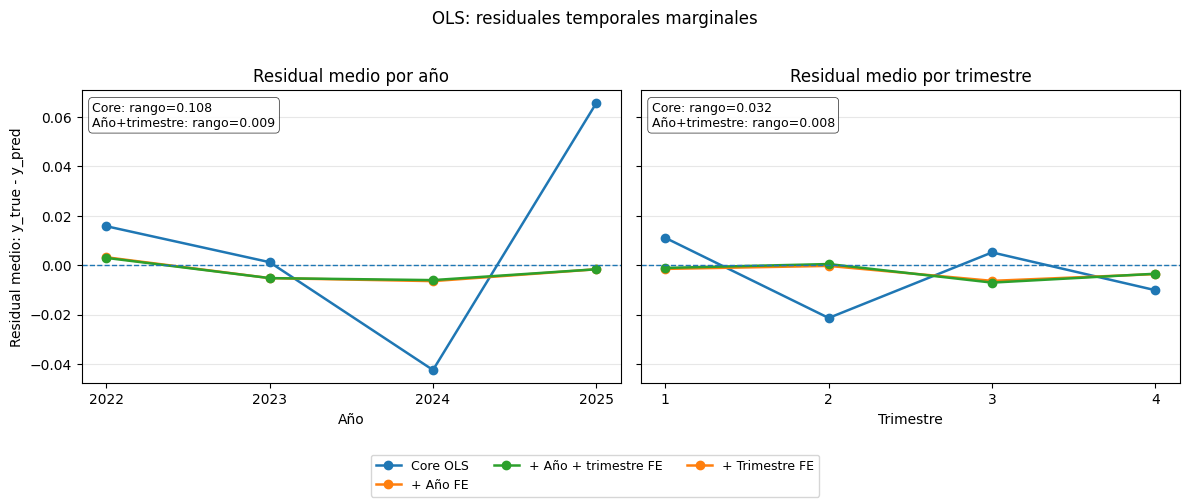

In [9]:
def get_range_text(summary: pd.DataFrame, experiment: str) -> str:
    g = summary.query("split == 'validation' and experiment == @experiment")
    if g.empty:
        return "rango=NA"
    return f"rango={g['mean_residual'].max() - g['mean_residual'].min():.3f}"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

# Panel año
ax = axes[0]
for exp in ["ols_core", "ols_core_year_fe", "ols_core_year_plus_quarter_fe"]:
    tmp = validation_year.query("experiment == @exp").sort_values("ANO4")
    if tmp.empty:
        continue
    ax.plot(tmp["ANO4"].astype(str), tmp["mean_residual"], marker="o", linewidth=1.8, label=DISPLAY_LABELS[exp])
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Residual medio por año")
ax.set_xlabel("Año")
ax.set_ylabel("Residual medio: y_true - y_pred")
ax.grid(axis="y", alpha=0.3)
ax.text(0.02, 0.96,
        f"Core: {get_range_text(year_summary, 'ols_core')}\nAño+trimestre: {get_range_text(year_summary, 'ols_core_year_plus_quarter_fe')}",
        transform=ax.transAxes, va="top", ha="left", fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85, "linewidth": 0.5})

# Panel trimestre
ax = axes[1]
for exp in ["ols_core", "ols_core_quarter_fe", "ols_core_year_plus_quarter_fe"]:
    tmp = validation_quarter.query("experiment == @exp").sort_values("TRIMESTRE")
    if tmp.empty:
        continue
    ax.plot(tmp["TRIMESTRE"].astype(str), tmp["mean_residual"], marker="o", linewidth=1.8, label=DISPLAY_LABELS[exp])
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Residual medio por trimestre")
ax.set_xlabel("Trimestre")
ax.grid(axis="y", alpha=0.3)
ax.text(0.02, 0.96,
        f"Core: {get_range_text(quarter_summary, 'ols_core')}\nAño+trimestre: {get_range_text(quarter_summary, 'ols_core_year_plus_quarter_fe')}",
        transform=ax.transAxes, va="top", ha="left", fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85, "linewidth": 0.5})

handles, labels = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[1].get_legend_handles_labels()
all_handles = handles + [h for h, l in zip(handles2, labels2) if l not in labels]
all_labels = labels + [l for l in labels2 if l not in labels]
fig.legend(all_handles, all_labels, loc="lower center", ncol=3, fontsize=9)
fig.suptitle("OLS: residuales temporales marginales", y=1.02)
fig.tight_layout(rect=[0, 0.12, 1, 1])
fig.savefig(FIG_DIR / "F1_v2_marginal_temporal_residuals_year_quarter.png", dpi=180, bbox_inches="tight")
plt.show()


## 09. Figura 2 — heatmap año×trimestre

La matriz año×trimestre muestra la estructura que no se ve en los márgenes. Esto es clave para no confundir:

```text
year FE + quarter FE
```

con:

```text
year × quarter FE
```

El modelo aditivo corrige niveles promedio de año y de trimestre, pero no tiene un parámetro específico para cada celda calendario.


/tmp/ipykernel_559625/3855795930.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


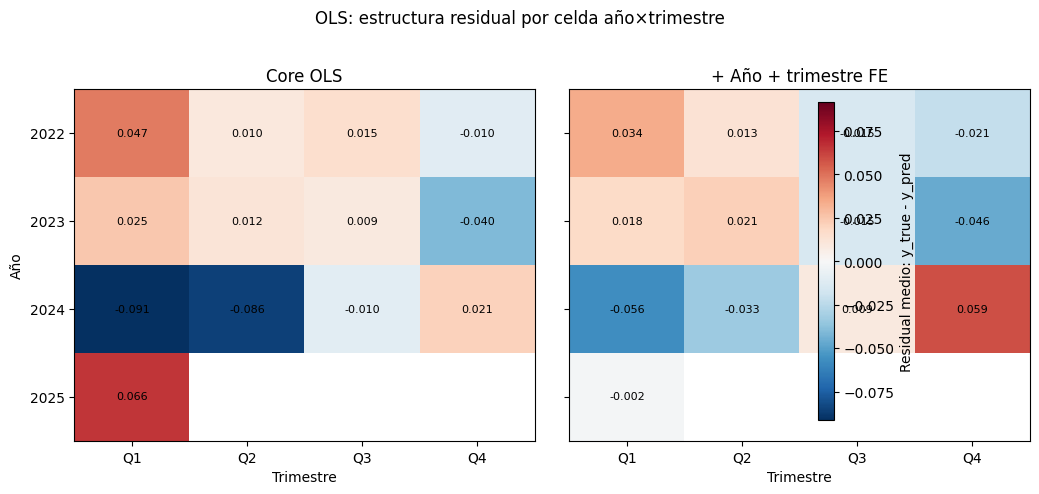

In [11]:
def year_quarter_matrix(df: pd.DataFrame, experiment: str, value_col="mean_residual") -> pd.DataFrame:
    tmp = df.query("experiment == @experiment").copy()
    matrix = tmp.pivot(index="ANO4", columns="TRIMESTRE", values=value_col)
    matrix = matrix.sort_index().sort_index(axis=1)
    return matrix

core_mat = year_quarter_matrix(validation_year_quarter, "ols_core")
yq_mat = year_quarter_matrix(validation_year_quarter, "ols_core_year_plus_quarter_fe")

all_vals = pd.concat([core_mat.stack(), yq_mat.stack()])
max_abs = float(np.nanmax(np.abs(all_vals))) if len(all_vals) else 0.1
max_abs = max(max_abs, 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8), sharex=True, sharey=True)
for ax, mat, title in [
    (axes[0], core_mat, "Core OLS"),
    (axes[1], yq_mat, "+ Año + trimestre FE"),
]:
    im = ax.imshow(mat.values, vmin=-max_abs, vmax=max_abs, cmap="RdBu_r", aspect="auto")
    ax.set_title(title)
    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels([f"Q{int(q)}" for q in mat.columns])
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels([str(int(y)) for y in mat.index])

    for i, year in enumerate(mat.index):
        for j, quarter in enumerate(mat.columns):
            value = mat.loc[year, quarter]
            if pd.isna(value):
                continue
            ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=8)

axes[0].set_ylabel("Año")
for ax in axes:
    ax.set_xlabel("Trimestre")

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.86)
cbar.set_label("Residual medio: y_true - y_pred")
fig.suptitle("OLS: estructura residual por celda año×trimestre", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "F2_v2_year_quarter_residual_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()


## 10. Figura 3 — media observada vs media predicha por año-trimestre

Esta figura pregunta si la estructura temporal residual proviene de una dinámica real del ingreso medio que el core no puede seguir completamente.

La descomposición intuitiva es:

```text
media observada del ingreso
=
media predicha por composición observable
+
residual temporal promedio
```

Si `mean(y_true)` se mueve más que `mean(y_pred_core)`, los FE temporales están capturando nivel temporal no explicado por la composición observada.


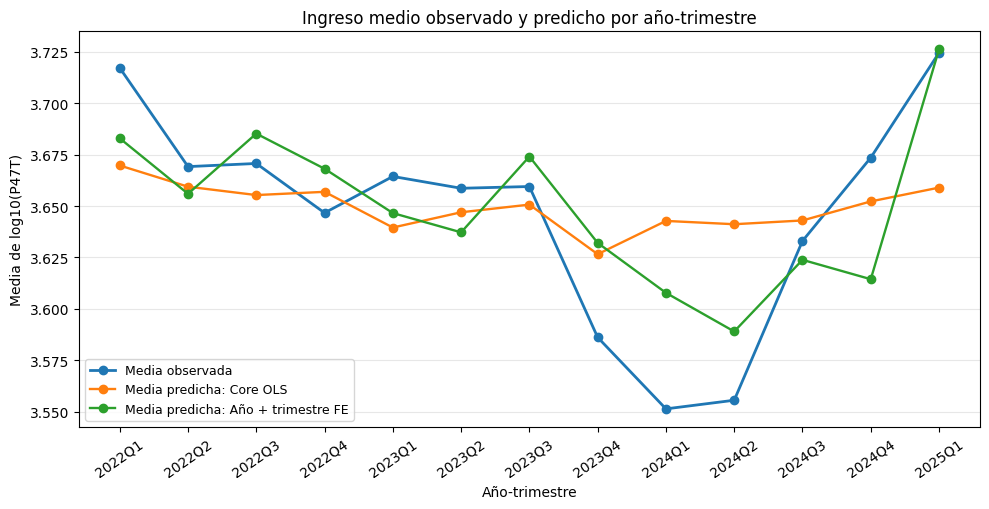

In [12]:
temporal_means = (
    validation_year_quarter
    .sort_values(["ANO4", "TRIMESTRE"])
    [["experiment", "ANO4", "TRIMESTRE", "year_quarter", "year_quarter_order", "n", "mean_y_true", "mean_y_pred", "mean_residual"]]
    .copy()
)
temporal_means.to_csv(TABLE_DIR / "T8_v2_ols_temporal_means_by_year_quarter.csv", index=False)

core_series = temporal_means.query("experiment == 'ols_core'").sort_values("year_quarter_order")
yq_series = temporal_means.query("experiment == 'ols_core_year_plus_quarter_fe'").sort_values("year_quarter_order")

fig, ax = plt.subplots(figsize=(10, 5.2))
if not core_series.empty:
    ax.plot(core_series["year_quarter"], core_series["mean_y_true"], marker="o", linewidth=2.0, label="Media observada")
    ax.plot(core_series["year_quarter"], core_series["mean_y_pred"], marker="o", linewidth=1.7, label="Media predicha: Core OLS")
if not yq_series.empty:
    ax.plot(yq_series["year_quarter"], yq_series["mean_y_pred"], marker="o", linewidth=1.7, label="Media predicha: Año + trimestre FE")

ax.set_title("Ingreso medio observado y predicho por año-trimestre")
ax.set_xlabel("Año-trimestre")
ax.set_ylabel("Media de log10(P47T)")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "F3_v2_mean_observed_vs_predicted_by_year_quarter.png", dpi=180, bbox_inches="tight")
plt.show()


## 11. Coeficientes de fixed effects

Los coeficientes FE no son medias crudas. Son diferencias ajustadas respecto de una categoría omitida, luego de controlar por `X`.

Se cargan si el backend los escribió. Si no existen, las tablas de residuales por grupo siguen siendo el diagnóstico principal.


In [13]:
def find_fe_coefficient_files(run_dir: Path) -> list[Path]:
    diagnostics_dir = run_dir / "diagnostics"
    if not diagnostics_dir.exists():
        return []
    patterns = [
        "*fixed_effect*coefficients*.csv",
        "*FixedEffect*coefficients*.csv",
        "*fe*coefficients*.csv",
    ]
    files = []
    for pattern in patterns:
        files.extend(diagnostics_dir.glob(pattern))
    return sorted(set(files))


fe_parts = []
for experiment, run_dir in RUNS.items():
    if run_dir is None:
        continue
    for path in find_fe_coefficient_files(run_dir):
        df = pd.read_csv(path)
        df["experiment"] = experiment
        df["label"] = DISPLAY_LABELS.get(experiment, experiment)
        df["source_file"] = str(path.relative_to(run_dir))
        fe_parts.append(df)

fe_coefficients = pd.concat(fe_parts, ignore_index=True) if fe_parts else pd.DataFrame()

if fe_coefficients.empty:
    print("No se encontraron archivos de coeficientes FE. Usar diagnósticos de residuales por tiempo.")
else:
    fe_coefficients.to_csv(TABLE_DIR / "T9_v2_ols_temporal_fixed_effect_coefficients_raw.csv", index=False)
    display(fe_coefficients.head(80))


,run_id,model,fe_name,level,feature,coefficient,abs_coefficient,sign,rank,experiment,label,source_file
0,ols_core_year_fe_20260611T050813Z,LinearRegression,year_fe,2025,cat__fe_year_fe_2025,0.053916,0.053916,positive,1,ols_core_year_fe,+ Año FE,diagnostics/fixed_effect_coefficients.csv
1,ols_core_year_fe_20260611T050813Z,LinearRegression,year_fe,2024,cat__fe_year_fe_2024,-0.049777,0.049777,negative,2,ols_core_year_fe,+ Año FE,diagnostics/fixed_effect_coefficients.csv
2,ols_core_year_fe_20260611T050813Z,LinearRegression,year_fe,2023,cat__fe_year_fe_2023,-0.006941,0.006941,negative,3,ols_core_year_fe,+ Año FE,diagnostics/fixed_effect_coefficients.csv
3,ols_core_quarter_fe_20260611T050827Z,LinearRegression,quarter_fe,2,cat__fe_quarter_fe_2,-0.033697,0.033697,negative,1,ols_core_quarter_fe,+ Trimestre FE,diagnostics/fixed_effect_coefficients.csv
4,ols_core_quarter_fe_20260611T050827Z,LinearRegression,quarter_fe,4,cat__fe_quarter_fe_4,-0.019161,0.019161,negative,2,ols_core_quarter_fe,+ Trimestre FE,diagnostics/fixed_effect_coefficients.csv
5,ols_core_quarter_fe_20260611T050827Z,LinearRegression,quarter_fe,3,cat__fe_quarter_fe_3,-0.001120,0.001120,negative,3,ols_core_quarter_fe,+ Trimestre FE,diagnostics/fixed_effect_coefficients.csv
6,ols_core_year_plus_quarter_fe_20260611T050839Z,LinearRegression,year_fe,2025,cat__fe_year_fe_2025,0.052922,0.052922,positive,1,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,diagnostics/fixed_effect_coefficients.csv
7,ols_core_year_plus_quarter_fe_20260611T050839Z,LinearRegression,year_fe,2024,cat__fe_year_fe_2024,-0.050049,0.050049,negative,2,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,diagnostics/fixed_effect_coefficients.csv
8,ols_core_year_plus_quarter_fe_20260611T050839Z,LinearRegression,year_fe,2023,cat__fe_year_fe_2023,-0.007039,0.007039,negative,3,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,diagnostics/fixed_effect_coefficients.csv
9,ols_core_year_plus_quarter_fe_20260611T050839Z,LinearRegression,quarter_fe,2,cat__fe_quarter_fe_2,-0.016926,0.016926,negative,1,ols_core_year_plus_quarter_fe,+ Año + trimestre FE,diagnostics/fixed_effect_coefficients.csv


## 12. Confirmación empírica de principios teóricos

Esta sección resume qué expectativas matemáticas se observan en los artifacts.

La idea central es que un FE incluido en el modelo debería absorber diferencias promedio del grupo que sobreviven a los controles observables. En validation no esperamos residuales exactamente cero, pero sí una reducción fuerte si la estructura generaliza.


In [14]:
def get_range(summary: pd.DataFrame, experiment: str) -> float:
    g = summary.query("split == 'validation' and experiment == @experiment")
    if g.empty:
        return np.nan
    return g["mean_residual"].max() - g["mean_residual"].min()


def get_mean_abs_group_residual(summary: pd.DataFrame, experiment: str) -> float:
    g = summary.query("split == 'validation' and experiment == @experiment")
    if g.empty:
        return np.nan
    return g["mean_residual"].abs().mean()


theory_checks = pd.DataFrame([
    {
        "principio": "Year FE corrige márgenes anuales",
        "expectativa": "El rango del residual medio por año cae al agregar year FE.",
        "evidencia": f"Core={get_range(year_summary, 'ols_core'):.5f}; Year FE={get_range(year_summary, 'ols_core_year_fe'):.5f}; Year+Quarter FE={get_range(year_summary, 'ols_core_year_plus_quarter_fe'):.5f}",
    },
    {
        "principio": "Quarter FE corrige márgenes trimestrales",
        "expectativa": "El rango del residual medio por trimestre cae al agregar quarter FE.",
        "evidencia": f"Core={get_range(quarter_summary, 'ols_core'):.5f}; Quarter FE={get_range(quarter_summary, 'ols_core_quarter_fe'):.5f}; Year+Quarter FE={get_range(quarter_summary, 'ols_core_year_plus_quarter_fe'):.5f}",
    },
    {
        "principio": "Año domina sobre trimestre",
        "expectativa": "La deriva anual del core es mayor que la estacionalidad trimestral del core.",
        "evidencia": f"Rango anual core={get_range(year_summary, 'ols_core'):.5f}; rango trimestral core={get_range(quarter_summary, 'ols_core'):.5f}",
    },
    {
        "principio": "FE aditivos no son interacciones",
        "expectativa": "Year+Quarter FE reduce márgenes, pero puede dejar estructura año×trimestre.",
        "evidencia": f"Rango año×trimestre core={get_range(year_quarter_summary, 'ols_core'):.5f}; Year+Quarter FE={get_range(year_quarter_summary, 'ols_core_year_plus_quarter_fe'):.5f}",
    },
])

theory_checks.to_csv(TABLE_DIR / "T10_v2_ols_temporal_theory_checks.csv", index=False)
theory_checks


,principio,expectativa,evidencia
0,Year FE corrige márgenes anuales,El rango del residual medio por año cae al agr...,Core=0.10804; Year FE=0.00967; Year+Quarter FE...
1,Quarter FE corrige márgenes trimestrales,El rango del residual medio por trimestre cae ...,Core=0.03242; Quarter FE=0.00605; Year+Quarter...
2,Año domina sobre trimestre,La deriva anual del core es mayor que la estac...,Rango anual core=0.10804; rango trimestral cor...
3,FE aditivos no son interacciones,"Year+Quarter FE reduce márgenes, pero puede de...",Rango año×trimestre core=0.15705; Year+Quarter...


## 13. Resumen diagnóstico automático

Estas notas son un apoyo para lectura y para escribir claims. No reemplazan la interpretación científica.


In [15]:
def fmt(x, digits=5):
    if pd.isna(x):
        return "NA"
    return f"{x:.{digits}f}"

summary = validation_summary.set_index("experiment")
notes = []

for exp in ["ols_core_year_fe", "ols_core_quarter_fe", "ols_core_year_plus_quarter_fe"]:
    if exp in summary.index and "ols_core" in summary.index:
        notes.append(
            f"{DISPLAY_LABELS[exp]}: ΔR² vs core = {fmt(summary.loc[exp, 'delta_r2_vs_core'])}; "
            f"ΔMAE = {fmt(summary.loc[exp, 'delta_mae_vs_core'])}; "
            f"ΔRMSE = {fmt(summary.loc[exp, 'delta_rmse_vs_core'])}."
        )

notes.append(
    "Deriva temporal del core por año: "
    f"max-min residual medio = {fmt(get_range(year_summary, 'ols_core'))}."
)
notes.append(
    "Estacionalidad residual del core por trimestre: "
    f"max-min residual medio = {fmt(get_range(quarter_summary, 'ols_core'))}."
)
notes.append(
    "Rango residual año×trimestre: "
    f"core = {fmt(get_range(year_quarter_summary, 'ols_core'))}; "
    f"year+quarter FE = {fmt(get_range(year_quarter_summary, 'ols_core_year_plus_quarter_fe'))}."
)
notes.append(
    "Lectura teórica: los FE temporales corrigen márgenes incluidos, pero la especificación aditiva año+trimestre no elimina necesariamente shocks específicos de celdas año×trimestre."
)

DIAGNOSTIC_SUMMARY = "\n".join(f"- {note}" for note in notes)
print(DIAGNOSTIC_SUMMARY)
(TABLE_DIR / "T11_v2_ols_temporal_diagnostic_notes.txt").write_text(DIAGNOSTIC_SUMMARY, encoding="utf-8")


- + Año FE: ΔR² vs core = 0.00641; ΔMAE = -0.00116; ΔRMSE = -0.00157.
- + Trimestre FE: ΔR² vs core = 0.00113; ΔMAE = -0.00031; ΔRMSE = -0.00028.
- + Año + trimestre FE: ΔR² vs core = 0.00692; ΔMAE = -0.00132; ΔRMSE = -0.00169.
- Deriva temporal del core por año: max-min residual medio = 0.10804.
- Estacionalidad residual del core por trimestre: max-min residual medio = 0.03242.
- Rango residual año×trimestre: core = 0.15705; year+quarter FE = 0.11558.
- Lectura teórica: los FE temporales corrigen márgenes incluidos, pero la especificación aditiva año+trimestre no elimina necesariamente shocks específicos de celdas año×trimestre.


637

## 14. Interpretación provisional

Los fixed effects temporales agregan poca capacidad predictiva global al OLS core, pero revelan estructura temporal residual interpretable. La mayor parte del efecto temporal es anual: los residuales medios del core varían más entre años que entre trimestres, y `year FE` captura casi todo el incremento de performance.

La lectura no debe quedarse en ΔR². El resultado más importante es que los FE se comportan como predice la teoría: reducen los residuales medios de los grupos que incorporan. A la vez, la matriz año×trimestre muestra el límite de la especificación aditiva. `year + quarter FE` corrige márgenes anuales y trimestrales, pero no equivale a un conjunto completo de dummies `year × quarter`.

La figura de medias observadas y predichas permite conectar el resultado con una pregunta económica: qué parte de la dinámica temporal del ingreso medio queda explicada por cambios de composición observada y qué parte aparece como residual temporal. Esa discusión deberá reabrirse cuando se amplíe el período de datos.


## 15. Outputs escritos

Tablas:

```text
reports/notebook_outputs/ols_temporal_effects_v2/tables/
  T1_v2_ols_temporal_metrics_by_split.csv
  T2_v2_ols_temporal_validation_vs_core.csv
  T3_v2_ols_temporal_run_metadata.csv
  T4_v2_ols_temporal_residual_by_year.csv
  T5_v2_ols_temporal_residual_by_quarter.csv
  T6_v2_ols_temporal_residual_by_year_quarter.csv
  T7_v2_ols_temporal_residual_ranges.csv
  T8_v2_ols_temporal_means_by_year_quarter.csv
  T9_v2_ols_temporal_fixed_effect_coefficients_raw.csv
  T10_v2_ols_temporal_theory_checks.csv
  T11_v2_ols_temporal_diagnostic_notes.txt
```

Figuras:

```text
reports/notebook_outputs/ols_temporal_effects_v2/figures/
  F1_v2_marginal_temporal_residuals_year_quarter.png
  F2_v2_year_quarter_residual_heatmap.png
  F3_v2_mean_observed_vs_predicted_by_year_quarter.png
```

Criterio de aceptación:

- no hay barplots de cuatro números;
- las métricas agregadas están en tablas;
- las figuras muestran mecanismos, no decoración;
- año y trimestre se comparan con escalas consistentes;
- el heatmap separa márgenes de celdas año×trimestre;
- la notebook cierra con expectativas teóricas verificables.
